# Homework – Everything & Then Some, Ltd.: Prediction of Repurchase

**Main project goal:** predict if a customer will buy again within 90 days of the current purchase. Target: `repeat_purchase_90d`.

**Notebook Index:** 

**1. EDA + Data Understanding**
   Understand what the data contains, how reliable it is and what it implies for the next stages.
   Every issue found here is recorded in the final summary table together with the decision it
   triggers, so that the *Cleaning + Preprocessing* part can act on it.

**2. Cleaning + Preprocessing**

**3. Feature Selection**

**4. Model and Evaluation**

## 1. Exploratory Data Analysis and Data Understanding

### 1.1. Setup

In [98]:
# Library imports
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency, ks_2samp
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.metrics import roc_auc_score, mutual_info_score
from scipy.stats import ks_2samp

# Fixing seed
SEED = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 200)

# Makes the notebook runnable from other folders too
DATA = next(p for p in [Path('data'), Path('../data'), Path('.'), Path('/mnt/project')] if (p / 'train.csv').exists())

# Import CSV files
train_raw = pd.read_csv(DATA / 'train.csv', parse_dates=['purchase_date'])
test_raw = pd.read_csv(DATA / 'test.csv', parse_dates=['purchase_date'])
clientes = pd.read_csv(DATA / 'clientes.csv')
sample = pd.read_csv(DATA / 'sample_submission.csv')

print('Data folder:', DATA.resolve())

# Dimensions of the files
print('train', train_raw.shape, '| test', test_raw.shape, '| clientes', clientes.shape, '| sample_submission', sample.shape)

Data folder: C:\Users\Utilizador\Desktop\ML-project
train (6534, 39) | test (986, 38) | clientes (1143, 13) | sample_submission (986, 2)


**Why this setup:**
- **Fixed random seed (`SEED = 42`).** Some calculations use randomness internally (for example "mutual information" in section 1.7), by fixing the seed we get exactly the same numbers when running the notebook.
- **Dates are parsed on load (`parse_dates`).** In the CSV files, `purchase_date` is stored as plain text. Converting it to a real date type lets us sort purchases, find the first and last date, count purchases per month and compare the train and test periods.
- **Data folder.** The code looks for the CSV files in the `data/` folder of the repository, so the notebook runs the same way for every team member.

**File sizes:**
- **`train` (6,534 × 39):** 6,534 purchase occasions with 39 columns. This is a small dataset, so training is fast, but very complex models have a risk of overfitting.
- **`test` (986 × 38):** 986 purchases to predict. It has one column fewer than `train`: the target `repeat_purchase_90d`.
- **`clientes` (1,143 × 13):** customer-level table with 13 attributes.
- **`sample_submission` (986 × 2):** it has the same number of rows as `test`. Our final file must contain exactly one prediction (0 or 1) per test row, with the `ID` unchanged.

**Note:** Each row is a **purchase**, not a customer: the same customer appears in many rows.

### 1.2. Metadata and structure
The brief groups the variables as follows (the names of the monetary fields are Portuguese because they come from the company's invoicing system):

| Group | Variables | Meaning |
|---|---|---|
| Keys | `ID`, `customer_id` | `ID` = modelling row / Kaggle key; `customer_id` = join key to `clientes.csv` |
| Target | `repeat_purchase_90d` | 1 if the customer buys again within 90 days (train only) |
| Date | `purchase_date` | anonymised purchase date; order and intervals are preserved |
| Current money | `Total a Pagar`, `Total Bruto`, `Total Liquido`, `Total Imp_`, `Total Portes`, `Total Desc_ Global`, `Total Desc_ Linha`, `Custo` | amount due, gross, net, tax, shipping, global/line discounts, cost |
| Current detail | `N_ Detalhes`, `invoice_count_current_purchase` | number of detail lines and invoices in the purchase |
| Current categoricals | `payment_type`, `salesperson`, `commercial_zone`, `transport_method`, `warehouse`, `document_series` | how/where/by whom the sale was made |
| Historical timing | `days_since_previous_purchase`, `customer_tenure_days`, `prior_purchase_count`, `prior_mean_gap_days`, `prior_std_gap_days` | recency, tenure, history of gaps |
| Historical value | `prior_total_spend`, `prior_mean/std/min/max_purchase_value` | spend summaries before this purchase |
| Rolling activity | `purchase_count_{30,90,180,365}d`, `spend_{30,90,180,365}d` | frequency and spend in the previous windows |
| Control | `random_noise` | a column that may or may not carry information – to be tested |

Knowing what each field is tells us which ones are measured **before** the purchase (safe predictors) and which describe the purchase itself, and it lets us spot identifier-like fields.

In [99]:
print('Categorical: 6')
print('Numerical: 32')

train_raw.dtypes

Categorical: 6
Numerical: 32


Total a Pagar                            float64
Total Bruto                              float64
Total Liquido                            float64
Total Imp_                               float64
Total Portes                             float64
Total Desc_ Global                       float64
Total Desc_ Linha                        float64
Custo                                    float64
N_ Detalhes                              float64
invoice_count_current_purchase           float64
repeat_purchase_90d                        int64
days_since_previous_purchase             float64
customer_tenure_days                     float64
prior_purchase_count                     float64
prior_total_spend                        float64
prior_mean_purchase_value                float64
prior_std_purchase_value                 float64
prior_min_purchase_value                 float64
prior_max_purchase_value                 float64
prior_mean_gap_days                      float64
prior_std_gap_days  

In [100]:
print('Columns only in train:', sorted(set(train_raw.columns) - set(test_raw.columns)))
print('Columns only in test :', sorted(set(test_raw.columns) - set(train_raw.columns)))
dt = pd.DataFrame({'train_dtype': train_raw.dtypes.astype(str), 'test_dtype': test_raw.dtypes.astype(str)})
print('\nColumns whose dtype differs between train and test:')
display(dt[dt.train_dtype != dt.test_dtype])

Columns only in train: ['repeat_purchase_90d']
Columns only in test : []

Columns whose dtype differs between train and test:


,train_dtype,test_dtype
N_ Detalhes,float64,int64
customer_tenure_days,float64,int64
invoice_count_current_purchase,float64,int64
prior_purchase_count,float64,int64
purchase_count_180d,float64,int64
purchase_count_30d,float64,int64
purchase_count_365d,float64,int64
purchase_count_90d,float64,int64
repeat_purchase_90d,int64,NaN


**Insight:** the only column missing from the test set is the target, as expected. Several variables are `float` in train but `int` in test (e.g. `N_ Detalhes`, `customer_tenure_days`). This is a first hint that the training file has some rows with missing blocks.

### 1.3. Time Periods and ID variables
#### 1.3.1 Train and test time period
**How do the train and test periods relate in time?** The test purchases happen after the train purchases, so validation should mimic this: train on the past and validate on a later period. With a random split, the training set would contain purchases that happen *after* the ones being validated. Because each row's features record recent activity (e.g. `days_since_previous_purchase`, `purchase_count_90d`), those later rows reveal whether the customer bought again, which is exactly what the model is supposed to predict.

Train period: 2015-07-11 -> 2025-02-15
Test period : 2025-05-24 -> 2026-10-06


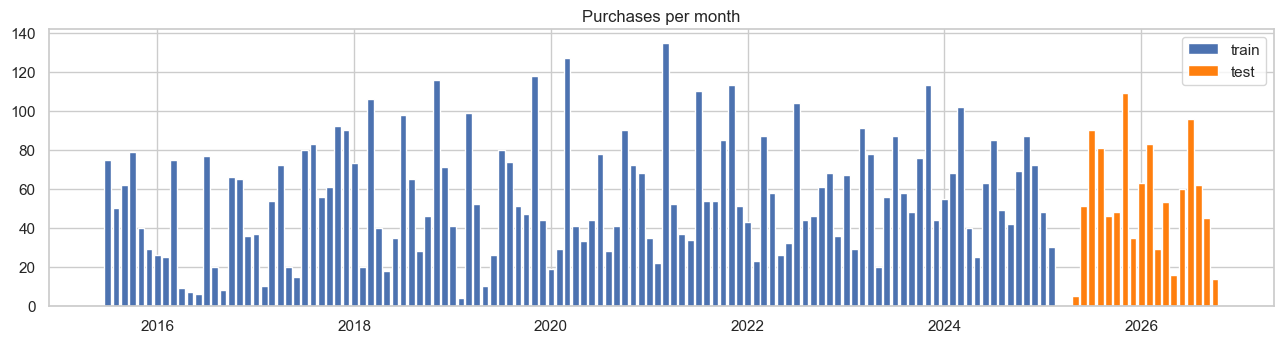

In [101]:
print('Train period:', train_raw.purchase_date.min().date(), '->', train_raw.purchase_date.max().date())
print('Test period :', test_raw.purchase_date.min().date(), '->', test_raw.purchase_date.max().date())
mtr = train_raw.purchase_date.dt.to_period('M').value_counts().sort_index() # monthly counts for train set
mte = test_raw.purchase_date.dt.to_period('M').value_counts().sort_index() # monthly counts for test set
fig, ax = plt.subplots(figsize=(13, 3.6))
ax.bar(mtr.index.to_timestamp(), mtr.values, width=25, label='train'); ax.bar(mte.index.to_timestamp(), mte.values, width=25, color='tab:orange', label='test')
ax.set_title('Purchases per month'); ax.legend(); plt.tight_layout(); plt.show()

In [102]:
rpc = train_raw.groupby('customer_id').size(); rpc_te = test_raw.groupby('customer_id').size()
print('Distinct customers –> train:', train_raw.customer_id.nunique(), '| test:', test_raw.customer_id.nunique())
print('\nRows per customer (train):'); print(rpc.describe().round(1).to_dict())
print('\nCustomers with a single training row:', round((rpc == 1).mean(), 3))
print('\nShare of TEST rows whose customer also appears in train:', round(test_raw.customer_id.isin(train_raw.customer_id).mean(), 3))
print('\nShare of TEST customers that appear in train           :', round(test_raw.customer_id.drop_duplicates().isin(train_raw.customer_id).mean(), 3))
print('\nDuplicate (customer, date) pairs in train:', int(train_raw.duplicated(['customer_id', 'purchase_date']).sum()))

Distinct customers –> train: 610 | test: 206

Rows per customer (train):
{'count': 610.0, 'mean': 10.7, 'std': 20.0, 'min': 1.0, '25%': 1.0, '50%': 4.0, '75%': 12.0, 'max': 277.0}

Customers with a single training row: 0.257

Share of TEST rows whose customer also appears in train: 0.945

Share of TEST customers that appear in train           : 0.893

Duplicate (customer, date) pairs in train: 12


**What this tells us:**
- The 6,534 training purchases come from only 610 customers: **rows are not independent**, because the same customer appears many times (on average ~11 times, but half of the customers have 4 purchases or fewer, and one customer has 277, possibly related to outliers).
- About 26% of customers appear only once, so for them there is little purchase history.
- **94.5% of test purchases belong to customers already in train** (89% of test customers). The model will mostly be predicting for customers it has seen. Since almost all test purchases come from customers already seen in training, our validation does not need to hold out whole customers. It is enough to split by time: train on earlier purchases and validate on later ones. So a temporal split *without* grouping by customer is better and this why in Section 4 we should not use `GroupKFold`.
- The ~11% (1 - 0.893) of test customers that are new have no history in train, so predictions for them are likely to be less reliable.
- 12 (customer, date) pairs are duplicated, meaning that the same customer has two rows on the same day. This is minor (0.2% of rows).

#### 1.3.2 Identifier-like variables
The assignment asks us to treat identifier-like variables critically. We check whether `ID` and `customer_id` carry any signal about the target or merely encode ordering.

In [103]:
# drops the 65 empty rows (they only have the IDs and the target, explained in Section 1.4)
train = train_raw[train_raw['Total Bruto'].notna()].copy()
for col in ['ID', 'customer_id']:
    # do purchases followed by a repurchase tend to have larger ID/customer_id numbers? (<0.5, tend to have smaller numbers | 0.5, it's a coin flip | >0.5, repeaters tend to have bigger numbers
    auc = roc_auc_score(train.repeat_purchase_90d, train[col])
    # do bigger ID/customer_id numbers go with later dates? (0 = no link with time | 1 = link with time)
    rho = train[col].corr(train.purchase_date.rank(), method='spearman') 
    print(f'{col:12s} AUC vs target = {auc:.3f} | Spearman with purchase date = {rho:.3f}')

ID           AUC vs target = 0.507 | Spearman with purchase date = 0.011
customer_id  AUC vs target = 0.433 | Spearman with purchase date = -0.022


**Insight:**
- **`ID`** tells us nothing about the target: its AUC is 0.51, which is a coin flip. It also does not follow time. The Spearman correlation with the purchase date is about 0 so `ID` is just a label.
- **`customer_id`** does not follow time either (Spearman ≈ −0.02). It has a weak lean toward the target (AUC 0.43, meaning purchases followed by a repurchase tend to have slightly smaller numbers). We cannot explain this from the data.
- Even a weak pattern in an identifier is a poor basis for prediction, because it does not describe customer behaviour. `customer_id` in particular would let flexible models memorise individual customers instead of learning patterns that apply to everyone.

**Decision:** `ID` is kept only as the submission key, and `customer_id` only as the key to join `clientes.csv`. Neither is used as a feature.

### 1.4. Data quality
Models silently learn from errors. We check missing values, impossible values and internal consistency before looking at relationships, so that later conclusions are not driven by artefacts.

#### 1.4.1. Missing values

In [104]:
miss = pd.DataFrame({'train_null_%': (train_raw.isna().mean() * 100).round(2), 'test_null_%': (test_raw.isna().mean() * 100).round(2), 'train_null_n': train_raw.isna().sum()})
miss = miss[(miss['train_null_n'] > 0) | (miss['test_null_%'] > 0)].sort_values('train_null_n', ascending=False)
display(miss)

,train_null_%,test_null_%,train_null_n
prior_std_gap_days,22.6200,7.0000,1478
prior_mean_gap_days,20.0200,7.7100,1308
prior_std_purchase_value,17.0300,4.6700,1113
prior_mean_purchase_value,13.1900,5.2700,862
days_since_previous_purchase,13.1800,5.2700,861
prior_max_purchase_value,10.2200,2.2300,668
prior_min_purchase_value,10.2200,2.2300,668
transport_method,3.9900,3.0400,261
spend_365d,3.9800,3.0400,260
payment_type,3.9800,3.0400,260


**The columns fall into three groups:**
- **24 columns with exactly 65 empty cells (0.99%)** (`Total Bruto`, `Custo`, `purchase_date`, `random_noise`...): these are the 65 blank rows (part A below).
- **5 columns with about 260 empty cells (4%)** (`payment_type`, `salesperson`, `transport_method`, `warehouse`, `spend_365d`): the 65 blank rows plus about 195 more (part B).
- **7 history columns with 668 to 1,478 empty cells** (`prior_*`, `days_since_previous_purchase`): customers without enough past purchases to compute the statistic (part C). Test has fewer of these (e.g. 7.0% vs. 22.6% for `prior_std_gap_days`) because test customers have longer histories.

In [105]:
# A. The 65 blank rows

blank = train_raw['Total Bruto'].isna()      # True for the rows where Total Bruto is empty (we will see they are empty everywhere)
print('Training rows with every transaction field empty:', int(blank.sum()))
print('Non-null columns in those rows:', list(train_raw[blank].columns[train_raw[blank].notna().any()]))   # only the IDs and the target have values
print('Target rate in those rows:', round(train_raw.loc[blank, 'repeat_purchase_90d'].mean(), 3), '| overall:', round(train_raw.repeat_purchase_90d.mean(), 3))   # similar rates = not a special group

Training rows with every transaction field empty: 65
Non-null columns in those rows: ['repeat_purchase_90d', 'customer_id', 'ID']
Target rate in those rows: 0.508 | overall: 0.559


**A. The 65 blank rows.** These rows have no values except `ID`, `customer_id` and the target. Their repeat rate (0.508) is close to the overall rate (0.559), so they are not a special group; if it had been, say, 100%, deleting them would have changed the data in a meaningful way. They carry no information and the test set has none, so we **drop them** in the cleaning stage (section 2).

In [106]:
# The 5 columns with ~3% of empty cells each (4 are text, spend_365d is a number)
# train = train without the 65 blank rows, test_raw = test file
cols5 = ['payment_type', 'salesperson', 'transport_method', 'warehouse', 'spend_365d']
print('Empty cells in these 5 columns (train without the 65 blank rows | test):')
print(pd.DataFrame({'train': train[cols5].isna().sum(), 'test': test_raw[cols5].isna().sum()}).T.to_string())

# Are the empty cells in the SAME rows? Take the rows where payment_type is empty and count how many are also empty in each other column
pt = train.payment_type.isna()
print('\nOf the', int(pt.sum()), 'train rows with an empty payment_type, how many are also empty in:',
      {c: int(train.loc[pt, c].isna().sum()) for c in cols5[1:]})
print('Rows with all 5 empty at once: train', int(train[cols5].isna().all(axis=1).sum()), '| test', int(test_raw[cols5].isna().all(axis=1).sum()))
print('Rows with at least one of the 5 empty: train', int(train[cols5].isna().any(axis=1).sum()), 'of', len(train),
      '| test', int(test_raw[cols5].isna().any(axis=1).sum()), 'of', len(test_raw))

Empty cells in these 5 columns (train without the 65 blank rows | test):
       payment_type  salesperson  transport_method  warehouse  spend_365d
train           195          194               196        195         195
test             30           30                30         30          30

Of the 195 train rows with an empty payment_type, how many are also empty in: {'salesperson': 4, 'transport_method': 2, 'warehouse': 7, 'spend_365d': 5}
Rows with all 5 empty at once: train 0 | test 0
Rows with at least one of the 5 empty: train 925 of 6469 | test 145 of 986


**B. Five columns with empty cells** (`payment_type`, `salesperson`, `transport_method`, `warehouse`, `spend_365d`). Each has about 195 empty cells in train and 30 in test (about 3%). The question was whether they are empty in the same rows (one problem) or in different rows (five problems). 

They are in **different rows**: among the 195 rows with an empty `payment_type`, only 2 to 7 are also empty in each of the other columns, and no row has all five empty. In total, 925 train rows (14.3%) and 145 test rows (14.7%) have at least one of the five empty. 

So each column is handled on its own: a "Missing" category for the four text columns, and the median (learned from train) for the numeric `spend_365d`. We **cannot delete** these rows, because test has the same gaps and every test row needs a prediction.

In [107]:
# History variables: a customer without enough past purchases has no history statistics
no_hist = train.prior_purchase_count == 0               # True = no previous purchase recorded
no_recency = train.days_since_previous_purchase.isna()  # True = "days since previous purchase" is empty
odd = no_recency & ~no_hist                             # empty recency although previous purchases exist

print('Rows with no previous purchase (prior_purchase_count = 0): train', int(no_hist.sum()), '| test', int((test_raw.prior_purchase_count == 0).sum()))
print('Rows with empty days_since_previous_purchase: train', int(no_recency.sum()), '| test', int(test_raw.days_since_previous_purchase.isna().sum()))
print('  of which have previous purchases (prior_purchase_count > 0):', int(odd.sum()))
print('  how many previous purchases those rows have (value: rows):', train.loc[odd, 'prior_purchase_count'].value_counts().sort_index().head(6).to_dict())
print('  smallest previous purchase (prior_min_purchase_value) is filled in:', int(train.loc[odd, 'prior_min_purchase_value'].notna().sum()), 'of', int(odd.sum()),
      '| empty in the no-history rows:', int(train.loc[no_hist, 'prior_min_purchase_value'].isna().sum()), 'of', int(no_hist.sum()))

print('\nTarget rate (share of purchases followed by a repurchase):')
print('  no previous purchase       :', round(train.loc[no_hist, 'repeat_purchase_90d'].mean(), 3))
print('  empty recency but history  :', round(train.loc[odd, 'repeat_purchase_90d'].mean(), 3))
print('  recency available          :', round(train.loc[~no_recency, 'repeat_purchase_90d'].mean(), 3))

# Is "no previous purchase recorded" really a first purchase? Check it with other columns (train)
print('\ncustomer_tenure_days == 0 -> no-history rows:', round((train.loc[no_hist, 'customer_tenure_days'] == 0).mean(), 3),
      '| rows with history:', round((train.loc[~no_hist, 'customer_tenure_days'] == 0).mean(), 3))
rows_per_customer = train[no_hist].groupby('customer_id').size()     # a customer can only have one first purchase
print('Customers with a no-history row:', len(rows_per_customer), '| with more than one:', int((rows_per_customer > 1).sum()), '| customers in train:', train.customer_id.nunique())
earliest_date = train.groupby('customer_id').purchase_date.transform('min')   # earliest date of each customer, repeated on all of their rows
print("No-history rows dated on the customer's earliest purchase date:", round((train.loc[no_hist, 'purchase_date'] == earliest_date[no_hist]).mean(), 3),
      '| rows with history:', round((train.loc[~no_hist, 'purchase_date'] == earliest_date[~no_hist]).mean(), 3))

# Same check in test (no target is used, we only look at how test is structured)
no_hist_test = test_raw.prior_purchase_count == 0
print('\nTest: customer_tenure_days == 0 -> no-history rows:', round((test_raw.loc[no_hist_test, 'customer_tenure_days'] == 0).mean(), 3),
      '| other rows:', round((test_raw.loc[~no_hist_test, 'customer_tenure_days'] == 0).mean(), 3))
print('Test: no-history rows whose customer also appears in train:', int(test_raw.loc[no_hist_test, 'customer_id'].isin(train.customer_id).sum()), 'of', int(no_hist_test.sum()))

Rows with no previous purchase (prior_purchase_count = 0): train 603 | test 22
Rows with empty days_since_previous_purchase: train 796 | test 52
  of which have previous purchases (prior_purchase_count > 0): 193
  how many previous purchases those rows have (value: rows): {1.0: 19, 2.0: 20, 3.0: 18, 4.0: 7, 5.0: 11, 6.0: 2}
  smallest previous purchase (prior_min_purchase_value) is filled in: 193 of 193 | empty in the no-history rows: 603 of 603

Target rate (share of purchases followed by a repurchase):
  no previous purchase       : 0.333
  empty recency but history  : 0.57
  recency available          : 0.583

customer_tenure_days == 0 -> no-history rows: 1.0 | rows with history: 0.0
Customers with a no-history row: 603 | with more than one: 0 | customers in train: 607
No-history rows dated on the customer's earliest purchase date: 1.0 | rows with history: 0.001

Test: customer_tenure_days == 0 -> no-history rows: 1.0 | other rows: 0.0
Test: no-history rows whose customer also appea

**C. History variables.**
- **First recorded purchases.** 603 train rows (9.3%) have no previous purchase recorded (`prior_purchase_count` = 0), versus 22 test rows (2.2%). We treat these as **first recorded purchases**: `customer_tenure_days` is 0 in all of them and in none of the other rows, each of the 603 customers has exactly one such row, and every one is dated on that customer's earliest purchase date. Test follows the same pattern (tenure 0 in all 22, and none of those customers appears in train). This does not exclude that a customer bought before the records start.
- **Empty recency.** `days_since_previous_purchase` is empty in 796 train rows (12.3%) and 52 test rows (5.3%). These are the 603 first recorded purchases plus **193 rows that are not first purchases**: they have previous purchases recorded (19 rows have 1, 20 have 2, 18 have 3, and so on, and the smallest previous purchase value is filled in for all 193) but no recency value.
- **Effect on the target.** First recorded purchases repurchase much less often (33.3%) than average. The 193 odd rows repurchase 57.0%, almost the same as rows with a recency value (58.3%).

**Consequence:**
- **First recorded purchases** (`prior_purchase_count` = 0) repurchase far less often (33%), so we create a flag for them. For these rows recency does not exist, so we fill it with the median learned from train and keep the flag.
- **The 193 rows with history but an empty recency** are not first purchases, and their repurchase rate is 57%, so the emptiness itself carries no signal. The value can be recomputed from the other previous purchase dates (at least for 192 of 193 of the rows). We recompute it instead of using the median.
- **Other empty history values** (for example `prior_mean_purchase_value` or `prior_mean_gap_days` with unexpected gaps) are filled with the median from the train set.

### 1.5. Descriptive statistics
After examining missing values, we inspect the distributions of the numerical variables and check for implausible or internally inconsistent values. Identifier columns and the target are excluded from the descriptive statistics because they are not numerical predictors.

In [108]:
ex = train.copy(); ex_te = test_raw.copy()          # exploration-only copies: implausible values hidden so that summaries are meaningful
for d in (ex, ex_te):
    for c in money: d.loc[(d[c] < 0) | (d[c] >= 1e9), c] = np.nan
num_cols = [c for c in ex.select_dtypes('number').columns if c not in ['ID', 'customer_id', 'repeat_purchase_90d']]
desc = ex[num_cols].describe(percentiles=[.01, .5, .99]).T
desc['skew'] = ex[num_cols].skew(); desc['max/p99'] = (desc['max'] / desc['99%'].replace(0, np.nan)).round(1)
display(desc[['count', 'mean', '50%', 'std', 'min', '99%', 'max', 'skew', 'max/p99']].round(2))

,count,mean,50%,std,min,99%,max,skew,max/p99
Total a Pagar,"6,469.0000",925.5600,476.7400,"1,335.0000",0.9300,"6,543.9700","22,297.2100",4.2100,3.4000
Total Bruto,"6,469.0000",886.1500,445.7400,"1,327.6400",0.8300,"6,717.6200","21,578.2800",4.3100,3.2000
Total Liquido,"6,469.0000",773.3400,389.9100,"1,136.3600",0.7600,"5,675.7000","18,127.8100",4.1500,3.2000
Total Imp_,"6,469.0000",152.2200,79.7400,225.2600,0.0000,"1,026.7900","4,169.4000",4.8400,4.1000
Total Portes,"6,469.0000",1.1500,0.0000,5.8400,0.0000,11.8000,181.0600,19.5500,15.3000
Total Desc_ Global,"6,469.0000",0.3500,0.0000,5.1200,0.0000,7.8500,218.4900,27.4600,27.8000
Total Desc_ Linha,"6,469.0000",112.4700,13.1300,289.9900,0.0000,"1,369.0400","4,103.4400",5.9200,3.0000
Custo,"6,469.0000",328.1700,152.5400,519.5100,0.0000,"2,382.1000","7,427.4000",4.6100,3.1000
N_ Detalhes,"6,469.0000",21.5200,11.0000,27.7100,1.0000,128.0000,423.0000,2.9800,3.3000
invoice_count_current_purchase,"6,469.0000",1.0700,1.0000,0.3100,1.0000,2.0000,5.0000,6.4400,2.5000


**Descriptive-statistics insigths**

Several monetary variables show strong right-skewness, with their means substantially higher than their medians. This is particularly noticeable for `prior_total_spend`, spend_90d, spend_180d, and spend_365d, suggesting the presence of high-value observations and potential outliers.

The most striking values are found in prior_mean_purchase_value and spend_365d, where the maximum is exactly 1,000,000,000 despite much smaller medians. This suggests that 1,000,000,000 may be an artificial placeholder rather than a genuine monetary value, so this value is investigated explicitly below.

Some variables also have negative minimum values, including prior_mean_purchase_value, spend_365d, days_since_previous_purchase, and prior_mean_gap_days. These values are potentially implausible given the meaning of the variables.

The purchase-frequency variables are relatively concentrated at low values, although some customers have substantially higher purchase counts. These variables may therefore capture meaningful differences in customer activity.

#### 1.5.1. Impossible values

In [109]:
money = ['prior_total_spend', 'prior_mean_purchase_value', 'prior_std_purchase_value', 'prior_min_purchase_value',
         'prior_max_purchase_value', 'spend_30d', 'spend_90d', 'spend_180d', 'spend_365d']
rep = []
for name, d in [('train', train), ('test', test_raw)]:
    rep.append((name, 'sentinel >= 1e9 in prior_mean_purchase_value', int((d.prior_mean_purchase_value >= 1e9).sum())))
    rep.append((name, 'sentinel >= 1e9 in spend_365d', int((d.spend_365d >= 1e9).sum())))
    rep.append((name, 'negative spend_365d', int((d.spend_365d < 0).sum())))
    rep.append((name, 'negative prior_mean_purchase_value', int((d.prior_mean_purchase_value < 0).sum())))
    rep.append((name, 'negative days_since_previous_purchase', int((d.days_since_previous_purchase < 0).sum())))
    rep.append((name, 'negative prior_mean_gap_days', int((d.prior_mean_gap_days < 0).sum())))
    rep.append((name, 'prior_max_purchase_value > prior_total_spend', int((d.prior_max_purchase_value > d.prior_total_spend + 1).sum())))
    rep.append((name, 'spend_90d > spend_180d', int((d.spend_90d > d.spend_180d + 1).sum())))
    rep.append((name, 'spend_180d > spend_365d', int((d.spend_180d > d.spend_365d + 1).sum())))
    rep.append((name, 'purchase_count_90d > purchase_count_365d', int((d.purchase_count_90d > d.purchase_count_365d).sum())))
    rep.append((name, 'prior_min > prior_max', int((d.prior_min_purchase_value > d.prior_max_purchase_value).sum())))
    rep.append((name, 'Custo > Total Liquido (cost above net sales)', int((d.Custo > d['Total Liquido']).sum())))
    rep.append((name, 'Total Liquido <= 0', int((d['Total Liquido'] <= 0).sum())))
anom = pd.DataFrame(rep, columns=['dataset', 'check', 'rows']).pivot(index='check', columns='dataset', values='rows')[['train', 'test']]
display(anom)

dataset,train,test
check,,
Custo > Total Liquido (cost above net sales),39,5
Total Liquido <= 0,0,0
negative days_since_previous_purchase,16,2
negative prior_mean_gap_days,16,2
negative prior_mean_purchase_value,16,2
negative spend_365d,15,2
prior_max_purchase_value > prior_total_spend,45,6
prior_min > prior_max,0,0
purchase_count_90d > purchase_count_365d,0,0


In [110]:
liq_resid = (train['Total Bruto'] - train['Total Desc_ Linha'] - train['Total Desc_ Global'] - train['Total Liquido']).abs()
pay_resid = (train['Total a Pagar'] - train['Total Liquido'] - train['Total Imp_'] - train['Total Portes'])
print('Net != Gross - discounts (tolerance 1):', int((liq_resid > 1).sum()))
print('Total due != Net + Tax + Shipping (tolerance 1):', int((pay_resid.abs() > 1).sum()), '| of which with Shipping > 0:', int(((pay_resid.abs() > 1) & (train['Total Portes'] > 0)).sum()))
print('Residual of those rows (median / min / max):', pay_resid[pay_resid.abs() > 1].agg(['median', 'min', 'max']).round(2).to_dict())

Net != Gross - discounts (tolerance 1): 0
Total due != Net + Tax + Shipping (tolerance 1): 1053 | of which with Shipping > 0: 1053
Residual of those rows (median / min / max): {'median': -4.89, 'min': -181.06, 'max': -1.86}


**Insights (anomalies and consistency)**
* **Sentinel values:** 16 training rows have `prior_mean_purchase_value` = 1,000,000,000 and 15 have `spend_365d` = 1,000,000,000 – an obviously artificial placeholder. The test set has 2 such rows, so they must be converted to missing and imputed (Section 2).
* **Negative values:** 16 rows have a negative `prior_mean_purchase_value` (about the same number have negative day gaps and negative `prior_mean_gap_days`) and 15 have a negative `spend_365d`. Negative amounts are implausible for these fields; a possible explanation is credit notes or returns netting against purchases, but the data cannot confirm it. Negative day gaps could be same-day purchases recorded out of order. Treatment: convert to missing / clip and report how many rows were affected.
* **Logical inconsistencies:** 45 rows have a maximum single purchase above the total prior spend and 15 have `spend_180d` > `spend_365d`, which cannot both be true. They are rare (< 1%) but show that some historical aggregates are not fully reliable. Therefore, these variables should not be interpreted in isolation, and their usefulness will be assessed during feature selection and model validation.
* **Accounting identity:** `Net = Gross − discounts` holds exactly. `Total a Pagar` deviates from `Net + Tax + Shipping` However, in 1,053 rows, `Total a Pagar` does not equal Total Liquido + Tax + Shipping. All of these cases have a positive shipping charge, and the discrepancy is consistently negative (median −4.89). This suggests that the difference is related to the invoicing system's treatment of shipping rather than random data corruption. Since the exact business rule is unknown, we keep the original values unchanged rather than applying an arbitrary correction.
* **Selling below cost:** `Custo > Total Liquido` occurs in only 39 training rows (≈ 0.6%). In wholesale this can be returns, promotions or credit notes, so these rows are **kept**; log-transforming (Section 2) is a safer response than removal.

#### 1.5.2. Skeweness

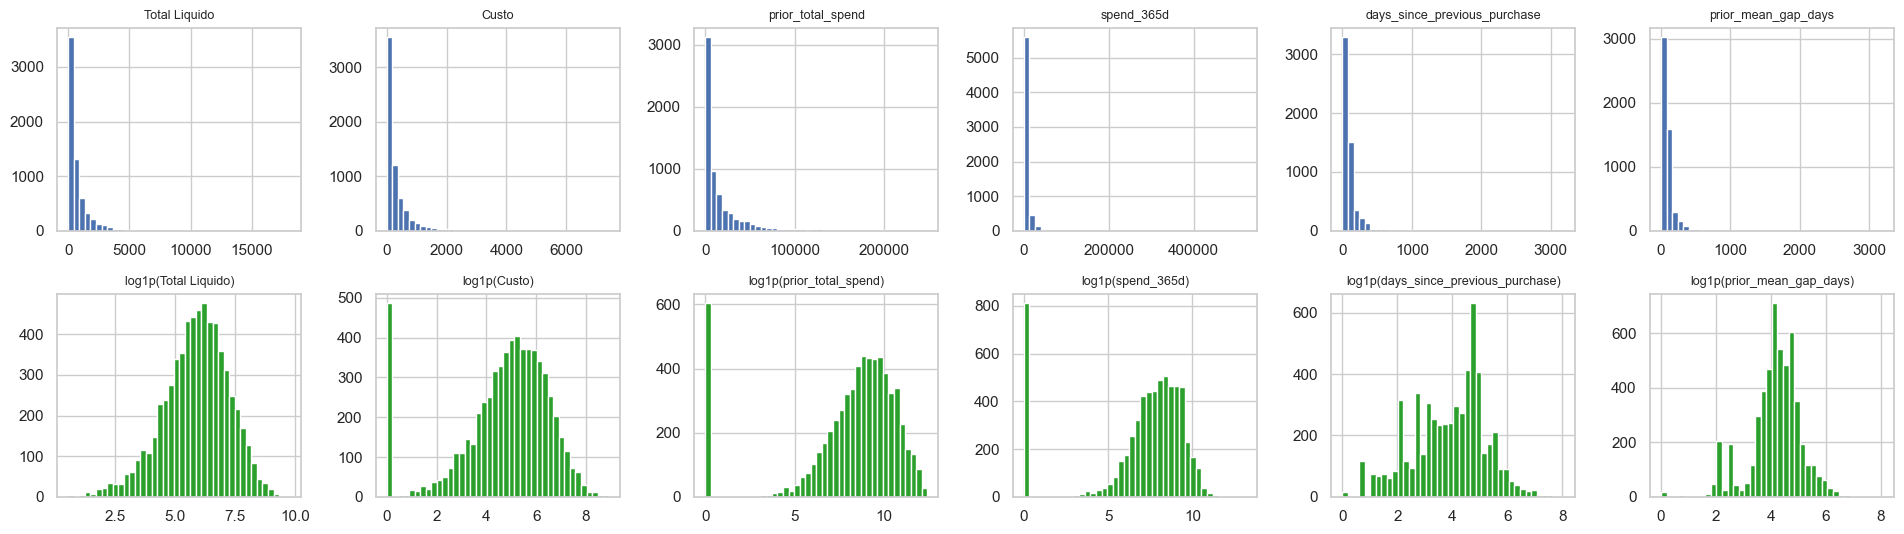

23 non-negative variables with skewness > 3: ['Total a Pagar', 'Total Bruto', 'Total Liquido', 'Total Imp_', 'Total Portes', 'Total Desc_ Global', 'Total Desc_ Linha', 'Custo', 'invoice_count_current_purchase', 'prior_purchase_count', 'prior_total_spend', 'prior_mean_purchase_value', 'prior_min_purchase_value', 'prior_max_purchase_value', 'prior_std_gap_days', 'purchase_count_30d', 'spend_30d', 'purchase_count_90d', 'spend_90d', 'purchase_count_180d', 'spend_180d', 'purchase_count_365d', 'spend_365d']


In [111]:
skewed = desc.index[(desc['skew'] > 3) & (ex[num_cols].min() >= 0)].tolist()
show = [c for c in ['Total Liquido', 'Custo', 'prior_total_spend', 'spend_365d', 'days_since_previous_purchase', 'prior_mean_gap_days'] if c in ex.columns]
fig, ax = plt.subplots(2, len(show), figsize=(3.2 * len(show), 5.5))
for j, c in enumerate(show):
    ex[c].dropna().clip(lower=0).plot.hist(bins=40, ax=ax[0, j]); ax[0, j].set_title(c, fontsize=9)
    np.log1p(ex[c].dropna().clip(lower=0)).plot.hist(bins=40, ax=ax[1, j], color='tab:green'); ax[1, j].set_title('log1p(' + c + ')', fontsize=9)
    ax[0, j].set_ylabel(''); ax[1, j].set_ylabel('')
plt.tight_layout(); plt.show()
print(f'{len(skewed)} non-negative variables with skewness > 3:', skewed)

#### Insights

* **Many numerical variables are strongly right-skewed.** 23 non-negative variables have skewness above 3, mainly monetary and purchase-frequency variables.

* **The distributions have long right tails.** `log1p` reduces the influence of extreme values and makes these variables less skewed.

* **Some artificial values were identified.** The `1e9` values in `prior_mean_purchase_value` and `spend_365d` should be treated as missing and imputed during preprocessing.

* **Transformations will depend on the model.** Scale-sensitive models can benefit from `log1p` and standardisation, while tree-based models generally do not require them.

* **Large values are not automatically removed.** In a wholesale setting, extreme purchases may be legitimate, so we prefer transformations over deleting observations.

* **Variables have very different scales.** Standardisation will therefore be considered for models that are sensitive to feature scale.

### 1.6. The target
Class balance decides which metrics are meaningful, and a drifting target rate over time would signal censoring or concept drift.

{1: 3621, 0: 2848} | rate of 1: 0.56


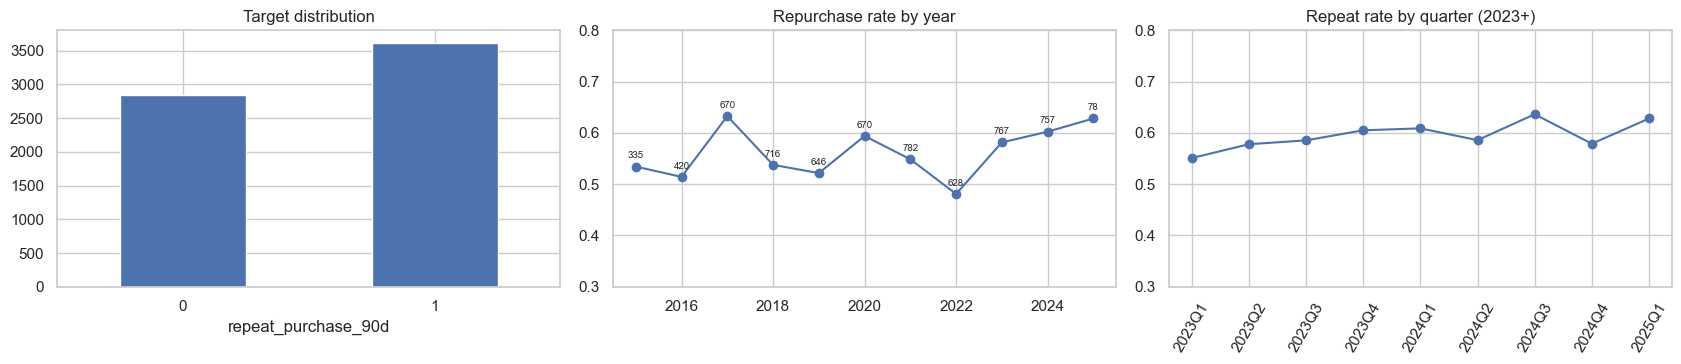

In [112]:
print(train.repeat_purchase_90d.value_counts().to_dict(), '| rate of 1:', round(train.repeat_purchase_90d.mean(), 3))
train['year'] = train.purchase_date.dt.year; train['quarter'] = train.purchase_date.dt.to_period('Q')
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
train.repeat_purchase_90d.value_counts().sort_index().plot.bar(ax=ax[0], rot=0); ax[0].set_title('Target distribution')
g = train.groupby('year').repeat_purchase_90d.agg(['mean', 'size']); ax[1].plot(g.index, g['mean'], marker='o'); ax[1].set_ylim(0.3, 0.8); ax[1].set_title('Repurchase rate by year')
for x, (m, n) in g.iterrows(): ax[1].annotate(int(n), (x, m), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7)
gq = train[train.year >= 2023].groupby('quarter').repeat_purchase_90d.mean(); ax[2].plot(gq.index.astype(str), gq.values, marker='o'); ax[2].set_ylim(0.3, 0.8); ax[2].tick_params(axis='x', rotation=60); ax[2].set_title('Repeat rate by quarter (2023+)')
plt.tight_layout(); plt.show()

**Insights**
* The classes are **moderately imbalanced** (about 56% positives). It is not extreme, so no resampling is needed, but accuracy alone would reward "always predict 1" (≈56%) -> use ROC-AUC and average precision / F1 in Section 4.
*  The yearly repurchase rate fluctuates between approximately 0.48 and 0.63, while recent quarterly rates remain between approximately 0.55 and 0.64. There is no clear decrease in the target rate towards the end of the training period. Therefore, we find no obvious evidence of right-censoring (purchases too recent to have a full 90-day follow-up being labelled 0) affecting the most recent observations, and we keep all training rows.
* We can use the last part of the training data as a validation set because it is the closest thing we have to the future test period. However, the test set goes further into the future than our training data, so the validation period may not perfectly represent the test period.

### 1.7. Numeric variables vs. target
Check which numerical variables are related to the target.

We use 3 different measures because they look at the relationship in different ways:

- **Spearman correlation:** checks whether the target tends to increase or decrease as the variable increases.
- **ANOVA F-test:** checks whether the variable has different average values for customers who repurchase and those who do not.
- **Mutual information:** can detect more complex relationships, including non-linear ones.

random_noise is included as a control variable. Since it was randomly generated, it should not contain useful information about the target. It therefore gives us a reference for what a variable with no real signal looks like.

,spearman,anova_F,anova_p,mutual_info,MI_rank
prior_max_purchase_value,0.2519,69.4985,0.0000,0.1591,1
prior_min_purchase_value,-0.2355,41.6749,0.0000,0.1433,2
purchase_count_365d,0.4370,847.2319,0.0000,0.1312,3
purchase_count_180d,0.4061,813.0609,0.0000,0.1094,4
prior_mean_gap_days,-0.4174,255.0710,0.0000,0.1038,5
purchase_count_90d,0.3928,779.2013,0.0000,0.0982,6
spend_365d,0.3875,225.0098,0.0000,0.0849,7
spend_180d,0.3695,644.3498,0.0000,0.0790,8
prior_std_gap_days,-0.3151,156.5779,0.0000,0.0728,9
prior_purchase_count,0.3456,634.0360,0.0000,0.0727,10


Control -> random_noise: {'spearman': -0.0082, 'anova_F': 0.9296, 'anova_p': 0.335, 'mutual_info': 0.0049, 'MI_rank': 26.0} | AUC alone: 0.495 | out of 29 variables


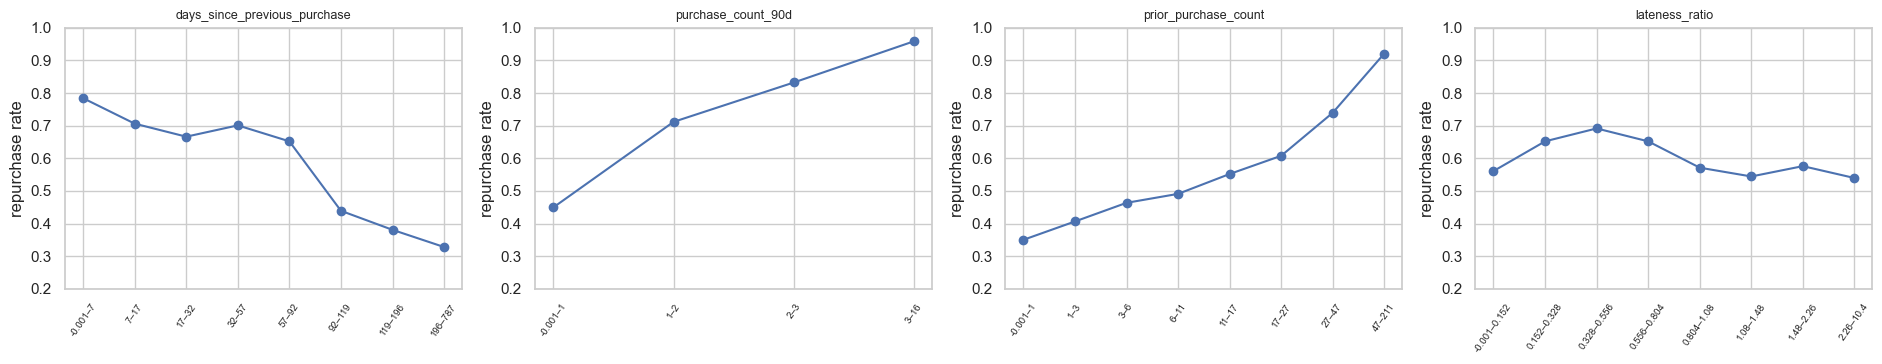

In [113]:
# Local copy for this analysis only: placeholders (1e9) and negative values are replaced by empty cells so that they do not
# distort the statistics (the real cleaning is done in Section 2). "money" is the list defined in 1.5.1
explore = train.copy()
for c in money:
    explore.loc[(explore[c] < 0) | (explore[c] >= 1e9), c] = np.nan
for c in ['days_since_previous_purchase', 'prior_mean_gap_days']:
    explore.loc[explore[c] < 0, c] = 0                                         # negative day gaps = same-day purchases

predictors = [c for c in num_cols if c not in ['ID', 'customer_id', 'repeat_purchase_90d']]    # numerical predictors only (no identifiers, no target)
y_train = explore.repeat_purchase_90d.values
X_filled = explore[predictors].fillna(explore[predictors].median())           # median fill ONLY here: the F-test and mutual information need complete data

F_stat, p_val = f_classif(X_filled, y_train)       # ANOVA F-test: do repeaters and non-repeaters have different average values?
univariate = pd.DataFrame({
    'spearman': explore[predictors].corrwith(explore.repeat_purchase_90d, method='spearman'),   # direction of the relationship
    'anova_F': F_stat, 'anova_p': p_val,
    'mutual_info': mutual_info_classif(X_filled, y_train, random_state=SEED)},                  # any kind of relationship
    index=predictors)
univariate['MI_rank'] = univariate.mutual_info.rank(ascending=False).astype(int)
pd.options.display.float_format = '{:,.4f}'.format
display(univariate.sort_values('mutual_info', ascending=False).head(15))
print('Control -> random_noise:', univariate.loc['random_noise'].round(4).to_dict(), '| AUC alone:', round(roc_auc_score(y_train, explore.random_noise), 3), '| out of', len(predictors), 'variables')

# Repurchase rate by bins of 4 variables (each bin holds about the same number of purchases)
def rate_by_bin(df, col, q=8):
    b = pd.qcut(df[col], q, duplicates='drop')
    return df.groupby(b, observed=True).repeat_purchase_90d.agg(['mean', 'size'])
explore['lateness_ratio'] = explore.days_since_previous_purchase / (explore.prior_mean_gap_days + 1)   # exploratory: is the customer late given their usual rhythm?
panels = ['days_since_previous_purchase', 'purchase_count_90d', 'prior_purchase_count', 'lateness_ratio']
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
for a, c in zip(ax, panels):
    r = rate_by_bin(explore.assign(**{c: explore[c].clip(upper=explore[c].quantile(.99))}), c)   # the largest 1% of values are capped for readability
    a.plot(range(len(r)), r['mean'].values, marker='o'); a.set_xticks(range(len(r))); a.set_xticklabels([f'{i.left:.3g}–{i.right:.3g}' for i in r.index], rotation=55, fontsize=7)
    a.set_ylim(0.2, 1.0); a.set_title(c, fontsize=9); a.set_ylabel('repurchase rate')
plt.tight_layout(); plt.show()

**Insights**

* **The analysis uses a temporary cleaned copy of the data.** For this exploratory analysis, the artificial 1e9 sentinel values and negative monetary values are replaced with missing values so that they do not distort the statistics. Negative values in the time-gap variables are temporarily treated as 0. Missing values are then filled with the median only for the statistical tests that require complete data. The original dataset is not changed here; the final treatment of these values is done in Section 2.
* **Recency and frequency are the strongest signals.** Variables that describe how often and how recently a customer has purchased are the most clearly related to the target. In particular, `purchase_count_365d`, `purchase_count_180d`, `purchase_count_90d`, `prior_purchase_count`, and `prior_mean_gap_days` show relatively strong relationships with repurchasing. The plots support this: customers who purchase more frequently are more likely to repurchase, while customers who have gone longer without purchasing are less likely to do so.

* **The 90-day horizon is particularly interesting.** There is a noticeable drop in the repurchase rate around the 90-day mark (1st grafic). This makes sense because the target itself is whether the customer makes another purchase within 90 days. Therefore, variables describing recent purchases are expected to be especially informative.

* **Different statistical tests highlight different variables.** Spearman correlation and ANOVA mainly identify variables where the target changes in a relatively clear way between customers. Mutual information can also detect more complex relationships. For example, `prior_max_purchase_value` and `prior_min_purchase_value` rank highly according to mutual information even though their Spearman correlations are only moderate. This suggests that their relationship with the target may not be simply increasing or decreasing.

* **`random_noise` behaves as expected.** It has an AUC close to 0.5, a correlation close to 0, a non-significant ANOVA result, and very low mutual information. This is what we would expect from a variable containing no useful information. It is therefore used as a control to help us identify variables whose apparent signal may simply be due to chance.

* **The `lateness_ratio` provides a weaker signal.** This variable compares the number of days since the customer's last purchase with their usual time between purchases. The relationship with repurchasing is not as clear as the relationship using `days_since_previous_purchase` alone. Therefore, it is kept as a feature to test later, but we cannot yet say that it improves the model.

* **These tests are only a first screening.** A variable that looks weak on its own may still be useful when combined with other variables. Therefore, we do not remove variables based only on these results. Feature selection and model validation will be used later to decide which variables are actually useful.


### 1.8. Categorical variables vs. target
We check whether categorical variables are related to the binary target using the chi-squared test and mutual information. We also check how many categories each variable has, whether some categories are very rare, and whether the test set contains categories that were not seen during training. These checks help us identify variables that may be useful, as well as potential overfitting and encoding problems.


In [114]:
cats = ['payment_type', 'salesperson', 'commercial_zone', 'warehouse', 'document_series', 'transport_method']
rows = []
for c in cats:
    col = train[c].fillna('Missing').astype(str); col_te = test_raw[c].fillna('Missing').astype(str)
    chi2, p, _, _ = chi2_contingency(pd.crosstab(col, train.repeat_purchase_90d))
    rows.append((c, col.nunique(), int((col.value_counts() < 30).sum()), int((~col_te.isin(col)).sum()), round(chi2, 1), p, round(mutual_info_score(col, train.repeat_purchase_90d), 4)))
cat_tab = pd.DataFrame(rows, columns=['variable', 'n_levels', 'levels_with_<30_rows', 'test_rows_with_unseen_level', 'chi2', 'p_value', 'mutual_info']).set_index('variable')
display(cat_tab.sort_values('mutual_info', ascending=False))

,n_levels,levels_with_<30_rows,test_rows_with_unseen_level,chi2,p_value,mutual_info
variable,,,,,,
transport_method,81,51,63,527.2000,0.0000,0.0488
payment_type,10,4,3,354.4000,0.0000,0.0340
salesperson,10,3,0,260.8000,0.0000,0.0205
commercial_zone,5,2,209,26.3000,0.0000,0.0021
warehouse,3,1,7,10.2000,0.0062,0.0008
document_series,3,0,0,0.1000,0.9727,0.0000


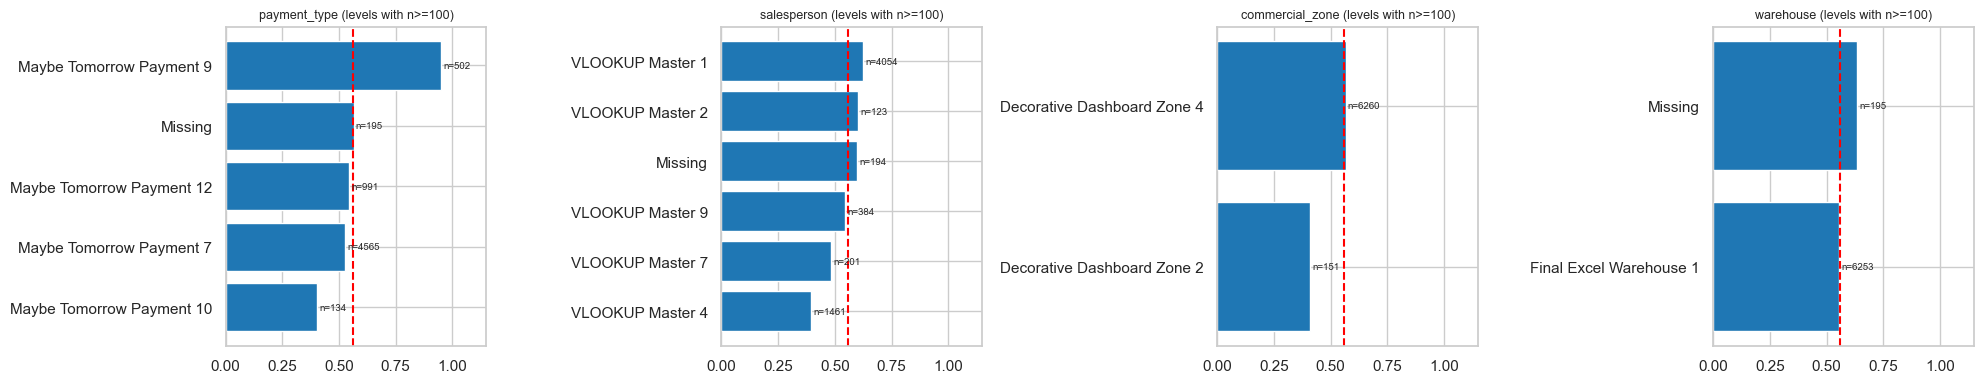

In [115]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, c in zip(ax, ['payment_type', 'salesperson', 'commercial_zone', 'warehouse']):
    g = train.assign(v=train[c].fillna('Missing')).groupby('v').repeat_purchase_90d.agg(['mean', 'size'])
    g = g[g['size'] >= 100].sort_values('mean')
    a.barh(g.index.astype(str), g['mean'], color='tab:blue'); a.axvline(train.repeat_purchase_90d.mean(), color='red', ls='--'); a.set_title(f'{c} (levels with n>=100)', fontsize=9)
    for i, (m, n) in enumerate(zip(g['mean'], g['size'])): a.text(m + .01, i, f'n={n}', va='center', fontsize=7)
    a.set_xlim(0, 1.15)
plt.tight_layout(); plt.show()

In [116]:
# Distribution shift in categorical levels: levels that exist in test but never in train, and the commercial_zone mix
for c in ['commercial_zone', 'transport_method', 'payment_type', 'warehouse']:
    seen = set(train[c].fillna('Missing')); vc = test_raw[c].fillna('Missing').value_counts()
    print(c, '-> test levels never seen in train:', {k: int(v) for k, v in vc.items() if k not in seen})
print()
print(pd.concat([train.commercial_zone.value_counts(normalize=True).rename('train_share'), test_raw.commercial_zone.value_counts(normalize=True).rename('test_share')], axis=1).round(3))

commercial_zone -> test levels never seen in train: {'Decorative Dashboard Zone 1': 189, 'Decorative Dashboard Zone 5': 20}
transport_method -> test levels never seen in train: {'Maybe Tomorrow Delivery 54': 58, 'Maybe Tomorrow Delivery 65': 5}
payment_type -> test levels never seen in train: {'Maybe Tomorrow Payment 5': 1, 'Maybe Tomorrow Payment 6': 1, 'Maybe Tomorrow Payment 1': 1}
warehouse -> test levels never seen in train: {'Final Excel Warehouse 2': 7}

                             train_share  test_share
commercial_zone                                     
Decorative Dashboard Zone 4       0.9680      0.7010
Decorative Dashboard Zone 2       0.0230      0.0780
Decorative Dashboard Zone 3       0.0090      0.0090
Decorative Dashboard Zone 6       0.0000         NaN
Decorative Dashboard Zone 7       0.0000         NaN
Decorative Dashboard Zone 1          NaN      0.1920
Decorative Dashboard Zone 5          NaN      0.0200


#### Insights

* **`payment_type` and `salesperson` show a clear relationship with the target.** Both have very small p-values, and the plots show noticeable differences in repurchase rates between categories. They are therefore potentially useful predictors.

* **`transport_method` has many categories, including many rare ones.** It has 81 different levels, and 51 of them have fewer than 30 observations. Its high mutual information and chi-squared values should therefore be interpreted with caution. Rare categories can be difficult for the model to learn reliably, so they should be grouped into an `"Other"` category during preprocessing.

* **`document_series` shows almost no relationship with the target.** Its p-value is 0.97 and its mutual information is essentially zero. It is therefore a candidate for removal during feature selection.

* **The distribution of some categorical variables changes considerably between train and test.** For example, `commercial_zone` is dominated by Zone 4 in train (about 97%), but Zone 4 represents only about 70% of the test set. In addition, Zone 1 and Zone 5 appear in the test set even though they were not observed in training.

* **Some unseen categories also appear in other variables.** There are 63 test rows with unseen `transport_method` values, 3 with unseen `payment_type` values, and 7 with unseen `warehouse` values. The encoding step therefore needs to handle unknown categories without producing errors.

* **Missing categorical values are treated as a separate `"Missing"` category.** This preserves the information that the original value was missing rather than removing those observations.

* **These results are exploratory.** We do not remove variables based only on these tests. A variable that looks weak on its own may still be useful when combined with other variables, so the final decision will be made using feature selection and model validation.


### 1.9. Multivariate structure
Strongly correlated inputs are redundant (and unstable for linear models). Knowing which groups are collinear tells the feature-selection part where to look.

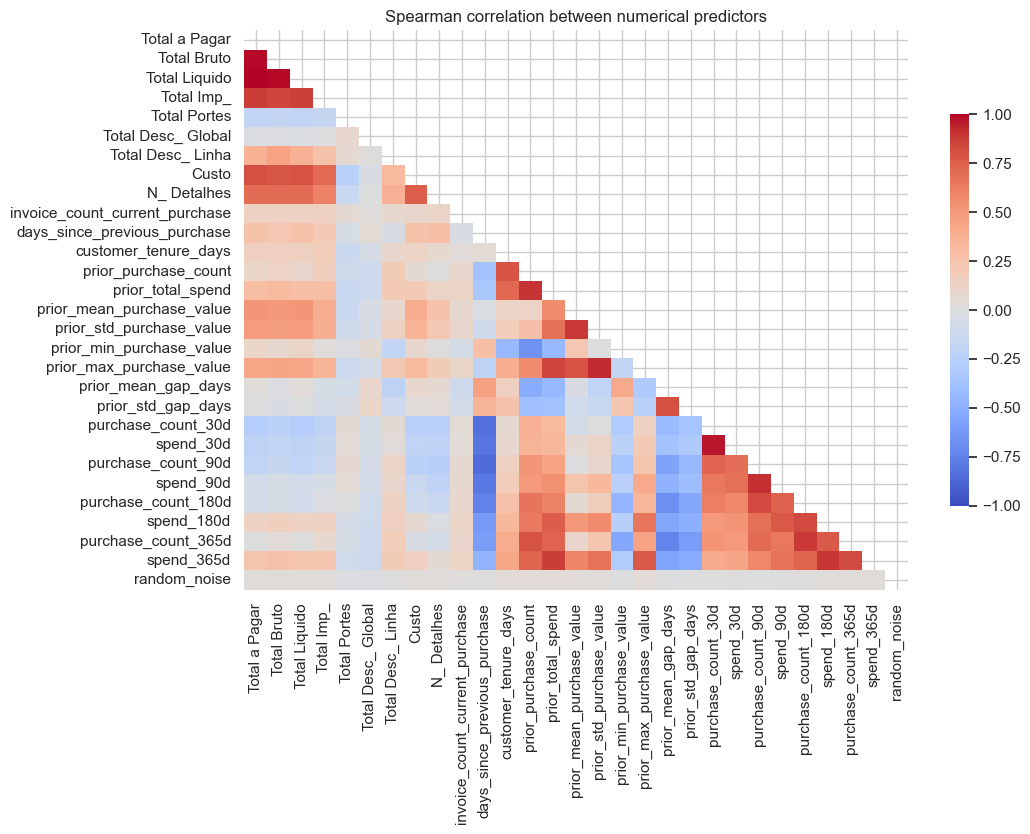

{'|rho|>0.95': 4, '|rho|>0.9': 7, '|rho|>0.8': 24} out of 406 pairs
Pairs with |rho| > 0.80 (top 20):


,variable_a,variable_b,rho,abs_rho
1,Total a Pagar,Total Liquido,1.0000,1.0000
28,Total Bruto,Total Liquido,0.9910,0.9910
0,Total a Pagar,Total Bruto,0.9910,0.9910
370,purchase_count_30d,spend_30d,0.9650,0.9650
316,prior_std_purchase_value,prior_max_purchase_value,0.9230,0.9230
385,purchase_count_90d,spend_90d,0.9090,0.9090
270,prior_purchase_count,prior_total_spend,0.9030,0.9030
401,spend_180d,spend_365d,0.8940,0.8940
397,purchase_count_180d,purchase_count_365d,0.8880,0.8880
301,prior_mean_purchase_value,prior_std_purchase_value,0.8830,0.8830


In [117]:
# Data for the correlations: numerical predictors only (no identifiers, no target).
# Placeholders (1e9) and negative values are hidden so that they do not distort the correlations
# (`money` is the list defined in 1.5.1; the real cleaning is done in section 2)
corr_data = train[[c for c in num_cols if c not in ['ID', 'customer_id', 'repeat_purchase_90d']]].copy()
for c in money:
    corr_data.loc[(corr_data[c] < 0) | (corr_data[c] >= 1e9), c] = np.nan
for c in ['days_since_previous_purchase', 'prior_mean_gap_days']:
    corr_data.loc[corr_data[c] < 0, c] = 0                      # negative day gaps = same-day purchases

corr_matrix = corr_data.corr(method='spearman')                 # empty cells are ignored pair by pair

# Heatmap: only the lower triangle is shown, so each pair appears once; colours go from -1 to +1
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': .7})
ax.set_title('Spearman correlation between numerical predictors'); plt.tight_layout(); plt.show()

# List every pair of variables once (upper triangle of the matrix) with its correlation
upper = np.triu_indices_from(corr_matrix, k=1)
pairs = pd.DataFrame({'variable_a': corr_matrix.index[upper[0]], 'variable_b': corr_matrix.columns[upper[1]], 'rho': corr_matrix.values[upper]})
pairs['abs_rho'] = pairs.rho.abs()                              # strength of the relationship, ignoring the sign

# How many pairs are strongly correlated?
print({f'|rho|>{t}': int((pairs.abs_rho > t).sum()) for t in (0.95, 0.9, 0.8)}, 'out of', len(pairs), 'pairs')
top_pairs = pairs[pairs.abs_rho > 0.80].sort_values('abs_rho', ascending=False)
print('Pairs with |rho| > 0.80 (top 20):')
display(top_pairs.head(20).round(3))

**Insights**

* **Most numerical variables are not strongly correlated.** Only 4 pairs have \(|ρ| > 0.95\) and 7 have \(|ρ| > 0.90\), so redundancy is concentrated in a few groups.
* **The strongest redundancy is among the transaction-value variables:** Total a Pagar, Total Liquido and Total Bruto have correlations above 0.99. These variables contain very similar information.
* **There is also strong correlation between purchase counts and spending** over the same period, for example purchase_count_30d and spend_30d (ρ = 0.97), and between historical purchase measures such as prior_purchase_count and prior_total_spend (ρ = 0.90).
* **The recent purchase behavoiur variables are also correlated with each other.** This is expected because, for example, purchases in the last 90 days are also part of the last 180 and 365 days.
* **For feature selection:** we should remove or select between highly redundant variables rather than keeping all of them. A threshold around \(|ρ| > 0.90\) is a reasonable starting point, although the final choice should be checked using model performance.

We use **Spearman** correlation because the numerical variables are often skewed and contain extreme values. Spearman measures whether two variables tend to increase/decrease together without assuming a linear relationship.

### 1.10. Train vs. test: does the test set look like the training set?
A model can only transfer to test if the inputs have similar distributions. We compare each numeric variable with the two-sample Kolmogorov–Smirnov statistic (0 = identical distributions, 1 = completely different). Only inputs are compared; the target is not available in test.

In [118]:
# Numerical predictors = numeric columns that exist in BOTH files (test has no target and no helper columns like `year`), without identifiers
predictor_cols = [c for c in num_cols if c in test_raw.columns and c not in ['ID', 'customer_id']]

# Placeholders (1e9) and negative values are hidden in BOTH files, so that they do not distort the comparison
# (`money` is the list defined in 1.5.1; the real cleaning is done in section 2)
def hide_implausible(df):
    d = df.copy()
    for c in money:
        d.loc[(d[c] < 0) | (d[c] >= 1e9), c] = np.nan
    for c in ['days_since_previous_purchase', 'prior_mean_gap_days']:
        d.loc[d[c] < 0, c] = 0                                   # negative day gaps = same-day purchases
    return d
train_view, test_view = hide_implausible(train), hide_implausible(test_raw)

# For each variable: KS statistic between train and test, plus the median in each file
rows = []
for c in predictor_cols:
    a, b = train_view[c].dropna(), test_view[c].dropna()
    rows.append((c, ks_2samp(a, b).statistic, a.median(), b.median()))
shift = pd.DataFrame(rows, columns=['variable', 'KS', 'median_train', 'median_test']).set_index('variable').sort_values('KS', ascending=False)
display(shift.head(10).round(3))
print('Median KS over all variables:', round(shift.KS.median(), 3))
print('random_noise (reference for "no drift"):', shift.loc['random_noise'].round(3).to_dict())

,KS,median_train,median_test
variable,,,
customer_tenure_days,0.4620,918.0000,"2,662.0000"
prior_total_spend,0.3180,"6,754.3100","25,186.5300"
prior_purchase_count,0.3130,11.0000,28.0000
prior_max_purchase_value,0.2560,"1,783.2400","3,198.0000"
Total Desc_ Linha,0.2430,13.1300,77.0800
spend_365d,0.2100,"2,426.6050","5,423.6500"
prior_mean_purchase_value,0.1820,724.8970,900.7650
prior_min_purchase_value,0.1800,64.3400,31.8800
prior_std_purchase_value,0.1540,569.0780,775.7750


Median KS over all variables: 0.126
random_noise (reference for "no drift"): {'KS': 0.04, 'median_train': -0.046, 'median_test': 0.037}


### Insights

* **Some variables are noticeably different between train and test.** The largest differences are found in `customer_tenure_days`, `prior_total_spend`, `prior_purchase_count`, and other variables that describe a customer's accumulated history.

* **These differences are expected because the test period is later in time.** As time passes, customers can accumulate more purchases, spend more money, and have longer relationships with the company. For example, the median `customer_tenure_days` increases from 918 days in train to 2,662 days in test.

* **The test set therefore represents a somewhat different population from the training set.** This is an important limitation because the model needs to make predictions for customers whose historical values can be larger than those commonly seen during training.

* **This reinforces the need for temporal validation.** A random train/validation split could hide these time-related differences. A temporal split is more realistic because it allows us to test whether a model trained on earlier data can predict observations from a later period.

* **The median KS statistic is 0.127.** This suggests that, although some variables show noticeable distribution shifts, the difference is not equally strong across all numerical variables.

* **We therefore keep these variables for now rather than removing them automatically.** Their usefulness will be evaluated during feature selection and model validation, using a validation setup that respects the temporal structure of the data.

### 1.11. The optional `clientes.csv` table
The brief makes this table optional. Before joining it we need to know whether it is complete, unique per customer and informative, and which of its columns are usable.

In [119]:
print('Rows:', len(clientes), '| unique customer_id:', clientes.customer_id.nunique(), '| duplicated IDs:', int(clientes.customer_id.duplicated().sum()))
print('Coverage – train rows with a customer record:', round(train.customer_id.isin(clientes.customer_id).mean(), 3), '| test rows:', round(test_raw.customer_id.isin(clientes.customer_id).mean(), 3))
print('Customers in clientes.csv that never appear in train/test:', int((~clientes.customer_id.isin(pd.concat([train_raw.customer_id, test_raw.customer_id]))).sum()))
info = pd.DataFrame({'dtype': clientes.dtypes.astype(str), 'null_%': (clientes.isna().mean() * 100).round(1), 'n_levels': clientes.nunique()})
info['levels_per_customer'] = (info.n_levels / len(clientes)).round(2)
display(info)

Rows: 1143 | unique customer_id: 1143 | duplicated IDs: 0
Coverage – train rows with a customer record: 1.0 | test rows: 1.0
Customers in clientes.csv that never appear in train/test: 511


,dtype,null_%,n_levels,levels_per_customer
customer_id,int64,0.0000,1143,1.0000
country_or_region,object,0.0000,11,0.0100
commercial_region,object,10.0000,37,0.0300
island,object,50.6000,10,0.0100
municipality,object,13.9000,183,0.1600
city,object,47.8000,417,0.3600
postal_area,object,6.2000,271,0.2400
postal_code,object,14.9000,828,0.7200
street,object,52.3000,511,0.4500
address,object,0.5000,1120,0.9800


Customer age at purchase (years): {'count': 6469.0, 'mean': 3.6, 'std': 2.7, 'min': 0.0, '25%': 1.0, '50%': 3.0, '75%': 6.0, 'max': 10.0} | negative: 0


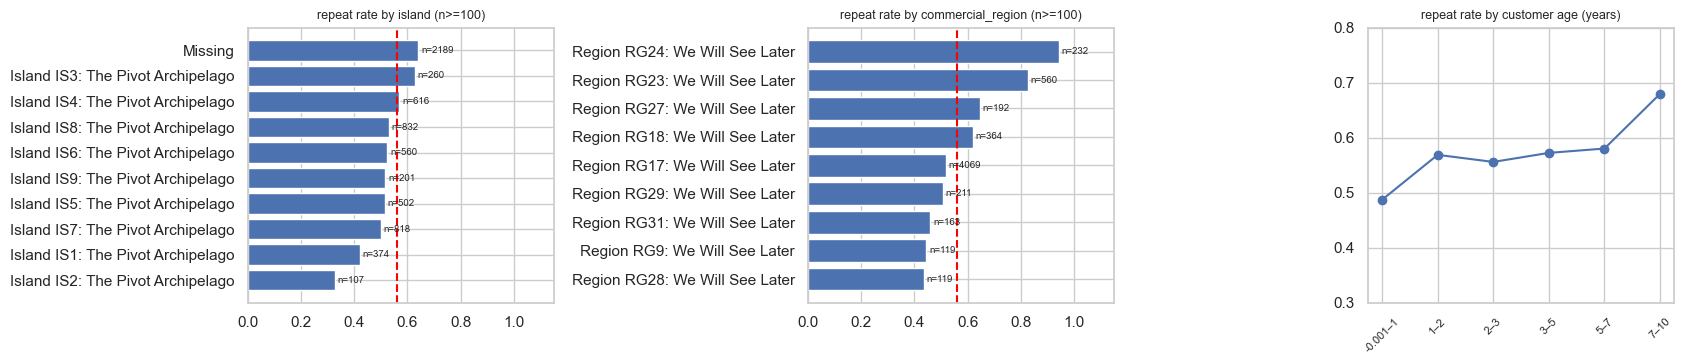

In [120]:
m = train.merge(clientes, on='customer_id', how='left')
m['customer_age_years'] = m.purchase_date.dt.year - m.customer_since_year
print('Customer age at purchase (years):', m.customer_age_years.describe().round(1).to_dict(), '| negative:', int((m.customer_age_years < 0).sum()))
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
for a, c in zip(ax[:2], ['island', 'commercial_region']):
    g = m.assign(v=m[c].fillna('Missing')).groupby('v').repeat_purchase_90d.agg(['mean', 'size']); g = g[g['size'] >= 100].sort_values('mean')
    a.barh(g.index.astype(str), g['mean']); a.axvline(m.repeat_purchase_90d.mean(), color='red', ls='--'); a.set_title(f'repeat rate by {c} (n>=100)', fontsize=9)
    for i, (mm, n) in enumerate(zip(g['mean'], g['size'])): a.text(mm + .01, i, f'n={n}', va='center', fontsize=7)
    a.set_xlim(0, 1.15)
rb = m.dropna(subset=['customer_age_years']); r = rate_by_bin(rb.assign(customer_age_years=rb.customer_age_years.clip(lower=0)), 'customer_age_years', 6)
ax[2].plot(range(len(r)), r['mean'].values, marker='o'); ax[2].set_xticks(range(len(r))); ax[2].set_xticklabels([f'{i.left:.3g}–{i.right:.3g}' for i in r.index], rotation=45, fontsize=8); ax[2].set_ylim(0.3, 0.8); ax[2].set_title('repeat rate by customer age (years)', fontsize=9)
plt.tight_layout(); plt.show()

**Insights and decision on integration**

* **The customer table is safe to join.** There are 1,143 customer records and all customer_id values are unique. Coverage is also complete: 100% of train and test rows have a matching customer record. Therefore, a left join on customer_id does not lose observations or create duplicate transaction rows.
* **Some customer variables are not suitable for modelling.**
- customer_type is completely missing and is therefore dropped.
- address, company_name, and postal_code have a very large number of unique values relative to the number of customers.These variables are close to customer identifiers and could allow the model to memorize individual customers rather than learn patterns that generalize.
- street, city, municipality, and postal_area are also either highly detailed or contain substantial missingness, so they are dropped rather than used in their raw form.
* **A small set of customer attributes is retained.** country_or_region, commercial_region, and island have relatively few categories and may capture broader customer characteristics. Their missing values are kept as a separate "Missing" category rather than removing the corresponding observations.
* **customer_since_year is transformed into customer age.** Instead of using the year directly, we calculate the customer's age at the time of purchase as purchase year − customer_since_year. The resulting variable ranges from 0 to 10 years, with no negative values, so no additional correction is needed.
* **Some customer attributes show differences in repurchase rates.** Repurchase rates vary across commercial regions and islands, and customer age also shows some variation across groups. However, these differences should be interpreted cautiously because some groups contain relatively few customers, and each customer can contribute multiple transaction rows. Therefore, the observed differences may partly reflect individual customer behaviour rather than a general regional effect.
* **The customer table is therefore integrated selectively.** We keep the broader geographic variables and customer age, while excluding near-identifiers and highly detailed address information. Whether this customer block actually improves prediction will be tested later comparing models with and without these variables.

### 1.12. Summary of findings and hand-off to the next parts
| **#** | **Finding**                                                                                                                                                                                                       | **Decision / action**                                                                                                                                                                          |
| ----- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1     | Each row represents a **purchase**, not a customer. The 6,534 training rows come from only 610 customers, so observations are not independent. 94.5% of test purchases belong to customers already seen in train. | Use a **temporal validation strategy without grouping by customer**. Mention repeated observations per customer as a limitation.                                                               |
| 2     | The same `(customer_id, date)` appears in 12 cases (0.2% of rows).                                                                                                                                                | Keep these observations; the duplication is rare and may represent multiple purchases on the same day.                                                                                         |
| 3     | `ID` and `customer_id` are identifiers rather than generalisable predictors.                                                                                                                                      | Exclude both from the feature matrix. Keep `ID` for the submission and `customer_id` for joining customer information.                                                                         |
| 4     | 65 training rows contain only `ID`, `customer_id`, and the target, with no transaction-level information.                                                                                                         | **Drop these rows** during cleaning.                                                                                                                                                           |
| 5     | Missing values fall into different groups: completely empty rows, missing transaction variables, and structural missingness in purchase-history variables.                                                        | Handle each type separately rather than applying one global missing-value rule.                                                                                                                |
| 6     | `payment_type`, `salesperson`, `transport_method`, `warehouse`, and `spend_365d` have missing values in both train and test. The missing values occur in different rows.                                          | Keep the observations. Use a **`"Missing"` category** for categorical variables and train-fitted imputation for `spend_365d`.                                                                  |
| 7     | First recorded purchases have `prior_purchase_count = 0` and a substantially lower repeat rate (33.3%). Some non-first purchases also have missing recency values.                                                | Create an **`is_first_purchase` flag**. Recompute missing recency when possible; otherwise use train-fitted imputation.                                                                        |
| 8     | Monetary variables are strongly right-skewed and contain extreme but potentially legitimate values.                                                                                                               | Use **`log1p` and standardisation for scale-sensitive models** where appropriate. Do not remove large purchases automatically.                                                                 |
| 9     | Artificial sentinel values of `10⁹` and implausible negative values occur in several variables in both train and test.                                                                                            | Convert identified invalid/sentinel values to **missing** and impute using values learned from the training data. Report the affected counts.                                                  |
| 10    | Some historical aggregates contain logical inconsistencies, such as `prior_max_purchase_value > prior_total_spend` and `spend_180d > spend_365d`.                                                                 | Keep the observations because the cases are rare, but treat these variables cautiously and let feature selection/model validation assess their usefulness.                                     |
| 11    | The accounting identity for `Total Liquido` holds exactly, while the difference involving `Total a Pagar` occurs mainly when shipping is positive.                                                                | Keep the original accounting values unchanged because the exact invoicing rule is unknown; do not apply an arbitrary correction.                                                               |
| 12    | The target is moderately imbalanced (~56% positive), with no clear decline in the repeat rate at the end of the training period.                                                                                  | Use **ROC-AUC, Average Precision and F1** rather than accuracy alone. No resampling is required initially. Keep the training observations.                                                     |
| 13    | Recency and frequency variables are the strongest univariate signals. Repeat rates change noticeably around the 90-day horizon.                                                                                   | Keep recency/frequency variables as important candidates. Test `lateness_ratio` and other derived features, but use model validation to decide whether they add value.                         |
| 14    | `random_noise` shows no meaningful signal (AUC ≈ 0.5, near-zero correlation and very low mutual information).                                                                                                     | Keep it as a **negative-control variable during experimentation**, but do not rely on it as a useful predictor.                                                                                |
| 15    | `payment_type` and `salesperson` show clear differences in repeat rates, while `document_series` shows essentially no relationship with the target.                                                               | Keep `payment_type` and `salesperson` as candidate predictors. **Drop `document_series`** if confirmed during feature selection.                                                               |
| 16    | `transport_method` has 81 levels, including many rare categories.                                                                                                                                                 | **Group rare categories into `"Other"`** inside the preprocessing pipeline.                                                                                                                    |
| 17    | Some categorical levels appear in test but not in train. `commercial_zone` also changes substantially between train and test.                                                                                     | Use an encoder that **handles unknown categories**. Evaluate whether `commercial_zone` should be simplified or removed based on validation performance.                                        |
| 18    | Numerical redundancy is concentrated in a few groups, especially `Total a Pagar`, `Total Liquido`, and `Total Bruto` (ρ > 0.99), as well as several count/spend pairs.                                            | Use ρ > 0.90 as a starting point for redundancy filtering, then check the effect on model performance.                                                                                   |
| 19    | Several numerical variables have noticeably different distributions in train and test, especially customer history variables. The median KS statistic is 0.127.                                                   | Keep the variables for now, but treat **distribution shift** as an important limitation and use temporal validation to assess generalisation.                                                  |
| 20    | `clientes.csv` has one unique record per customer and complete coverage for both train and test. Some fields are near-identifiers or too detailed, while broader geographic fields are potentially useful.        | Left-join only the **selected customer-level variables**. Drop `customer_type` and near-identifiers/address fields; keep `country_or_region`, `commercial_region`, `island`, and customer age. |
| 21    | Customer-level variables show differences in repurchase rates, but some regions contain relatively few customers and each customer contributes multiple purchases.                                                    | Treat these effects as **exploratory rather than causal**. Test the customer block with an ablation (with vs. without customer variables).                                                     |
| 22    | The dataset is relatively small (6,534 training rows), while some customers contribute many observations.                                                                                                         | Prefer reasonably simple models and use validation carefully to monitor **overfitting and generalisation**.                                                                                    |
